## 1. Import si Incarcare Date

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.naive_bayes        import GaussianNB
from sklearn.linear_model       import LogisticRegression
from sklearn.svm                import SVC
from sklearn.ensemble           import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing      import StandardScaler
from sklearn.metrics            import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, roc_auc_score, roc_curve, f1_score
)
from matplotlib.patches import Patch
import lightgbm as lgb

os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

train_df = pd.read_csv('v5_train.csv', index_col=0, parse_dates=True)
test_df  = pd.read_csv('v5_test.csv',  index_col=0, parse_dates=True)

with open('v5_feature_cols.json') as f:
    feature_cols_all = json.load(f)

with open('v5_data_meta.json') as f:
    meta_data = json.load(f)

# Eliminam features redundante identificate in analiza de corelatie
FEATURES_TO_DROP = ['Dist_52w_High', 'Realized_Vol_10d']
feature_cols     = [f for f in feature_cols_all if f not in FEATURES_TO_DROP]

print('Train:', len(train_df), 'saptamani | Test:', len(test_df), 'saptamani')
print('Features totale v5:', len(feature_cols_all))
print('Features eliminate:', FEATURES_TO_DROP)
print('Features finale:', len(feature_cols))
print(feature_cols)

Train: 342 saptamani | Test: 151 saptamani
Features totale V6: 20
Features eliminate: ['Dist_52w_High', 'Realized_Vol_10d']
Features finale: 18
['Return_1w', 'Return_4w', 'Dist_MA50', 'Dist_MA200', 'Dist_Local_Min', 'VIX', 'VIX_Ratio', 'VIX_Trend_20d', 'Volume_Ratio', 'RSI', 'SP500_Trend_20d', 'Phase', 'Yield_Curve', 'Yield_Curve_Change', 'Jobless_Ratio', 'Credit_Spread', 'Dollar_Change', 'Fed_Rate']


In [4]:
# Eliminam features redundante identificate in corelatie
FEATURES_TO_DROP = ['Dist_52w_High', 'Realized_Vol_10d']
feature_cols_clean = [f for f in feature_cols if f not in FEATURES_TO_DROP]

## 2. Pregatire X / y si Scalare

In [5]:
X_train_raw = train_df[feature_cols]
y_train     = train_df['label']
X_test_raw  = test_df[feature_cols]
y_test      = test_df['label']

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

ratio = (y_train == 0).sum() / (y_train == 1).sum()

print('Scalare completata.')
print('Raport Non-V / V-shape:', round(ratio, 2))
print('Train - Non-V:', (y_train==0).sum(), '| V-shape:', (y_train==1).sum())
print('Test  - Non-V:', (y_test==0).sum(),  '| V-shape:', (y_test==1).sum())

Scalare completata.
Raport Non-V / V-shape: 2.89
Train - Non-V: 254 | V-shape: 88
Test  - Non-V: 104 | V-shape: 47


## 3. Antrenare Modele

In [6]:
base_models = {
    'Naive Bayes': GaussianNB(),

    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),

    'SVM RBF': SVC(
        kernel='rbf', class_weight='balanced',
        probability=True, random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=5,
        class_weight='balanced', random_state=42
    ),

    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        is_unbalance=True, random_state=42, verbose=-1
    )
}

results = {}

for name, model in base_models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    acc     = accuracy_score(y_test, y_pred)
    auc     = roc_auc_score(y_test, y_proba)

    results[name] = {
        'model'  : model,
        'y_pred' : y_pred,
        'y_proba': y_proba,
        'acc'    : acc,
        'auc'    : auc
    }
    print(name.ljust(22), 'Accuracy:', round(acc, 3), '| ROC AUC:', round(auc, 3))

# Voting Ensemble: top 3 dupa AUC
top3       = sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True)[:3]
top3_names = [n for n, _ in top3]
print('\nTop 3 pentru Voting Ensemble:', top3_names)

ensemble = VotingClassifier(
    estimators=[(n, results[n]['model']) for n in top3_names],
    voting='soft'
)
ensemble.fit(X_train, y_train)
y_pred_ens  = ensemble.predict(X_test)
y_proba_ens = ensemble.predict_proba(X_test)[:, 1]
acc_ens     = accuracy_score(y_test, y_pred_ens)
auc_ens     = roc_auc_score(y_test, y_proba_ens)

results['Voting Ensemble'] = {
    'model'  : ensemble,
    'y_pred' : y_pred_ens,
    'y_proba': y_proba_ens,
    'acc'    : acc_ens,
    'auc'    : auc_ens
}
print('Voting Ensemble'.ljust(22), 'Accuracy:', round(acc_ens, 3), '| ROC AUC:', round(auc_ens, 3))
print('\nAntrenare completa.')

Naive Bayes            Accuracy: 0.735 | ROC AUC: 0.778
Logistic Regression    Accuracy: 0.543 | ROC AUC: 0.664
SVM RBF                Accuracy: 0.49 | ROC AUC: 0.523
Random Forest          Accuracy: 0.669 | ROC AUC: 0.675
LightGBM               Accuracy: 0.748 | ROC AUC: 0.754

Top 3 pentru Voting Ensemble: ['Naive Bayes', 'LightGBM', 'Random Forest']
Voting Ensemble        Accuracy: 0.742 | ROC AUC: 0.804

Antrenare completa.


## 4. Classification Report

In [7]:
separator = '=' * 50
for name, res in results.items():
    print(separator)
    print(name)
    print(separator)
    print(classification_report(y_test, res['y_pred'], target_names=['Non-V (0)', 'V-shape (1)']))
    print()

Naive Bayes
              precision    recall  f1-score   support

   Non-V (0)       0.86      0.74      0.79       104
 V-shape (1)       0.56      0.72      0.63        47

    accuracy                           0.74       151
   macro avg       0.71      0.73      0.71       151
weighted avg       0.76      0.74      0.74       151


Logistic Regression
              precision    recall  f1-score   support

   Non-V (0)       0.84      0.41      0.55       104
 V-shape (1)       0.39      0.83      0.53        47

    accuracy                           0.54       151
   macro avg       0.62      0.62      0.54       151
weighted avg       0.70      0.54      0.55       151


SVM RBF
              precision    recall  f1-score   support

   Non-V (0)       0.64      0.60      0.62       104
 V-shape (1)       0.22      0.26      0.24        47

    accuracy                           0.49       151
   macro avg       0.43      0.43      0.43       151
weighted avg       0.51      0.4

## 5. ROC Curves - V4 vs v5

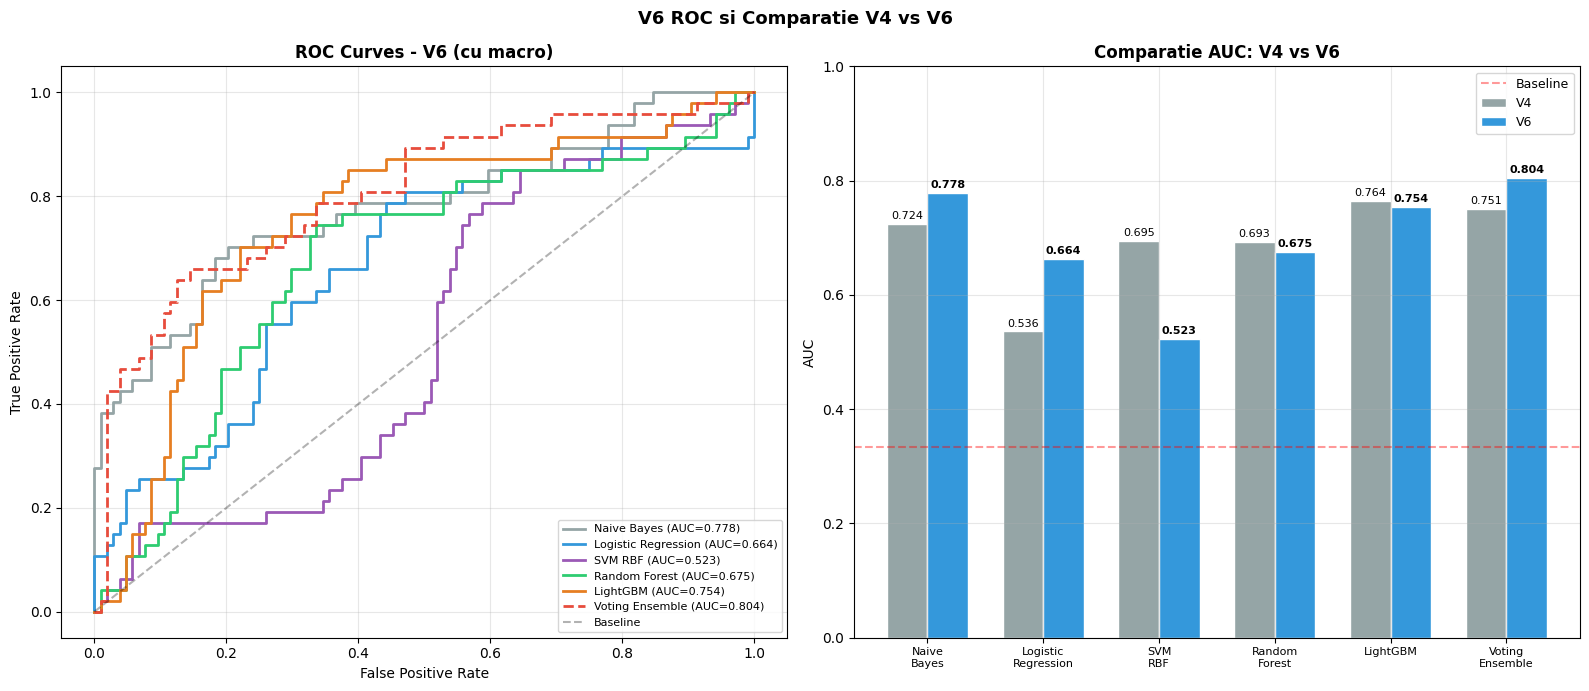

Salvat: plots/v6_roc_comparison.png


In [8]:
# AUC-uri V4 pentru comparatie directa
v4_aucs = {
    'Naive Bayes'        : 0.724,
    'Logistic Regression': 0.536,
    'SVM RBF'            : 0.695,
    'Random Forest'      : 0.693,
    'LightGBM'           : 0.764,
    'Voting Ensemble'    : 0.751
}

colors = ['#95a5a6', '#3498db', '#9b59b6', '#2ecc71', '#e67e22', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, title, aucs_ref in zip(
    axes,
    ['ROC Curves - v5 (cu macro)', 'Comparatie AUC: V4 vs v5'],
    [None, v4_aucs]
):
    if aucs_ref is None:
        # ROC curves v5
        for (name, res), color in zip(results.items(), colors):
            fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
            style = '--' if name == 'Voting Ensemble' else '-'
            ax.plot(fpr, tpr, color=color, linewidth=2, linestyle=style,
                    label=name + ' (AUC=' + str(round(res['auc'], 3)) + ')')
        ax.plot([0,1],[0,1],'k--',alpha=0.3,label='Baseline')
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.legend(loc='lower right', fontsize=8)
    else:
        # Comparatie V4 vs v5
        names  = list(results.keys())
        v4_vals = [aucs_ref[n] for n in names]
        v5_vals = [results[n]['auc'] for n in names]
        x = np.arange(len(names))
        w = 0.35

        bars1 = ax.bar(x - w/2, v4_vals, w, label='V4', color='#95a5a6', edgecolor='white')
        bars2 = ax.bar(x + w/2, v5_vals, w, label='v5', color='#3498db', edgecolor='white')

        for bar in bars1:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    str(round(bar.get_height(), 3)), ha='center', va='bottom', fontsize=8)
        for bar in bars2:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    str(round(bar.get_height(), 3)), ha='center', va='bottom',
                    fontsize=8, fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=8)
        ax.set_ylim(0, 1.0)
        ax.set_ylabel('AUC')
        ax.axhline(1/3, color='red', linestyle='--', alpha=0.4, label='Baseline')
        ax.legend(fontsize=9)
        ax.grid(True, axis='y', alpha=0.3)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('v5 ROC si Comparatie V4 vs v5', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/v5_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/v5_roc_comparison.png')

## 6. Threshold Optimization

Model selectat: Voting Ensemble
Threshold optim: 0.62
F1 V-shape la threshold optim: 0.659


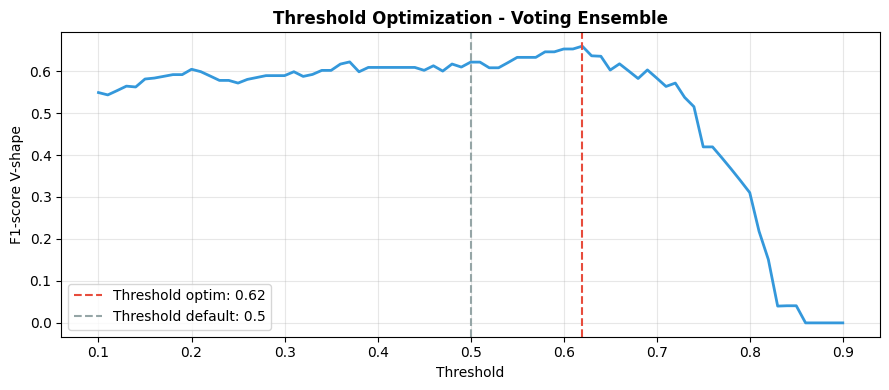

Salvat: plots/v6_threshold_optimization.png


In [9]:
best_model_name = max(results, key=lambda n: results[n]['auc'])
best_proba      = results[best_model_name]['y_proba']
print('Model selectat:', best_model_name)

thresholds = np.arange(0.10, 0.91, 0.01)
f1_scores  = [f1_score(y_test, (best_proba >= t).astype(int),
               pos_label=1, zero_division=0) for t in thresholds]

optimal_threshold = thresholds[np.argmax(f1_scores)]
optimal_f1        = max(f1_scores)

print('Threshold optim:', round(optimal_threshold, 2))
print('F1 V-shape la threshold optim:', round(optimal_f1, 3))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1_scores, color='#3498db', linewidth=2)
ax.axvline(optimal_threshold, color='#e74c3c', linestyle='--',
           label='Threshold optim: ' + str(round(optimal_threshold, 2)))
ax.axvline(0.5, color='#95a5a6', linestyle='--', label='Threshold default: 0.5')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1-score V-shape')
ax.set_title('Threshold Optimization - ' + best_model_name, fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/v5_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/v5_threshold_optimization.png')

## 7. Confusion Matrices

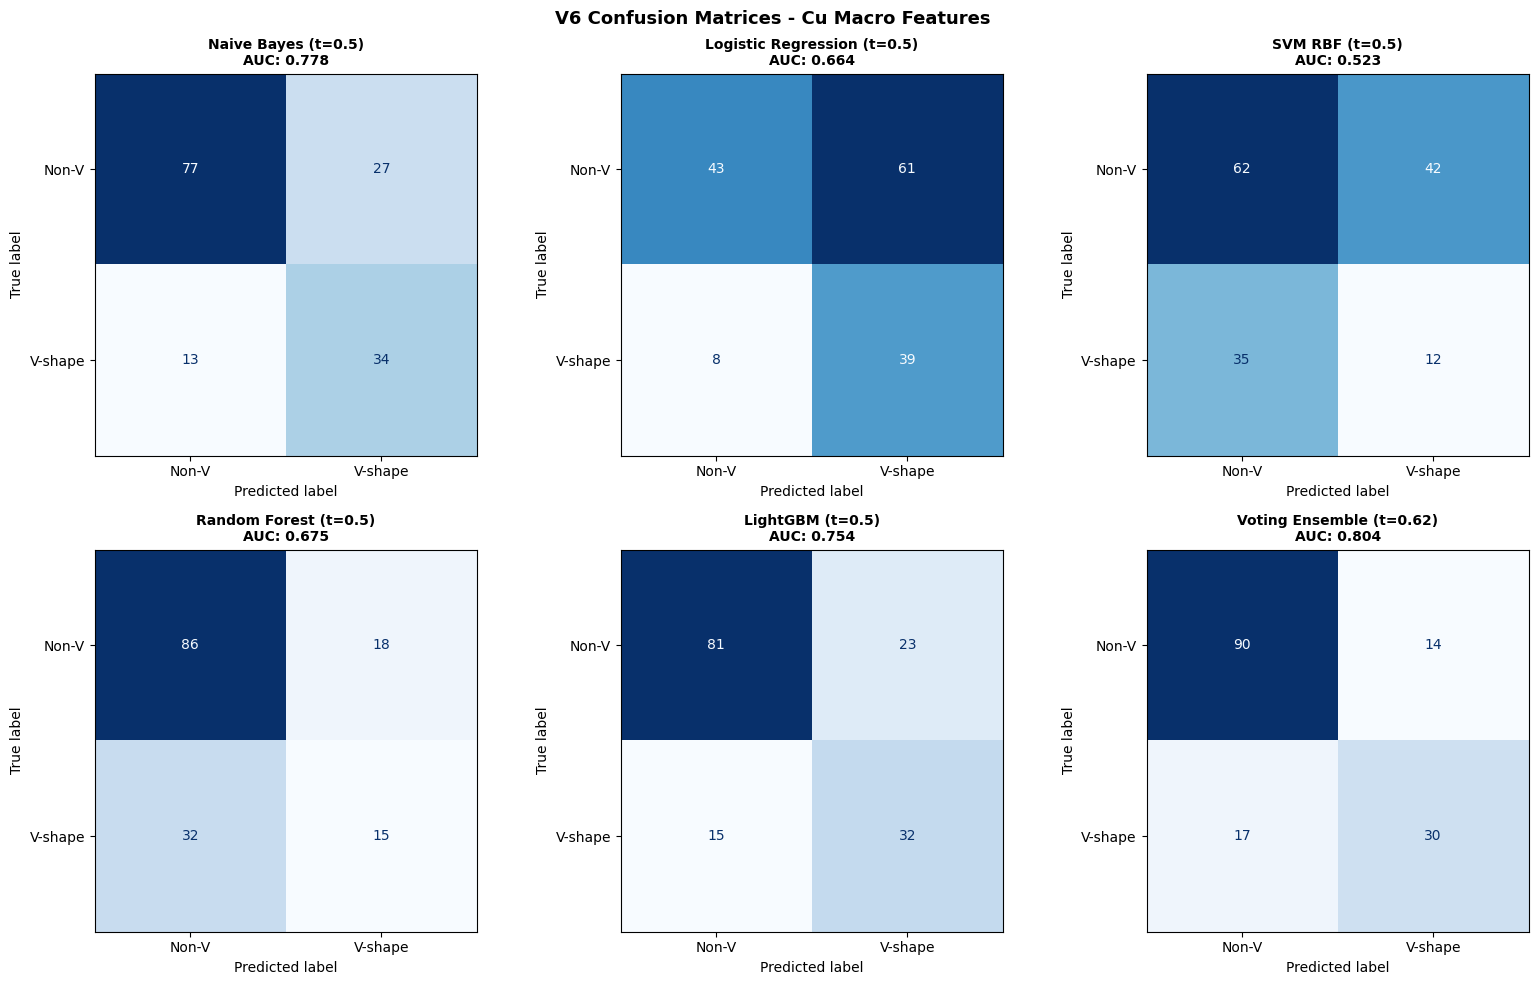

Salvat: plots/v6_confusion_matrices.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    if name == best_model_name:
        y_pred_plot  = (res['y_proba'] >= optimal_threshold).astype(int)
        title_suffix = ' (t=' + str(round(optimal_threshold, 2)) + ')'
    else:
        y_pred_plot  = res['y_pred']
        title_suffix = ' (t=0.5)'

    cm   = confusion_matrix(y_test, y_pred_plot)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-V', 'V-shape'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(
        name + title_suffix + '\nAUC: ' + str(round(res['auc'], 3)),
        fontsize=10, fontweight='bold'
    )

plt.suptitle('v5 Confusion Matrices - Cu Macro Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/v5_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/v5_confusion_matrices.png')

## 8. Feature Importance cu Macro Evidentiate

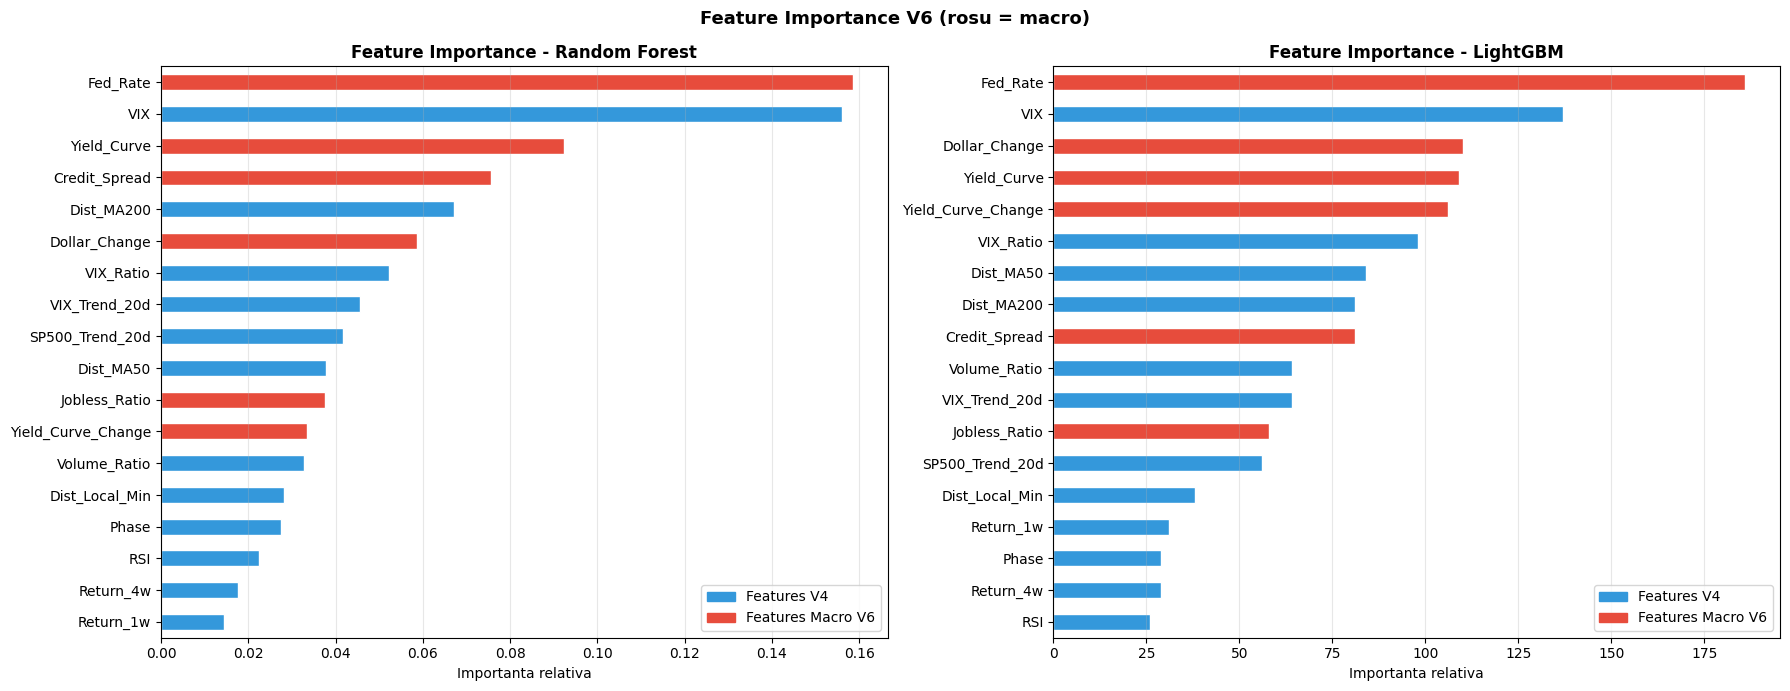

Salvat: plots/v6_feature_importance.png


In [11]:
macro_features = meta_data['feature_cols_macro']
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, model_name in zip(axes, ['Random Forest', 'LightGBM']):
    importances = pd.Series(
        results[model_name]['model'].feature_importances_,
        index=feature_cols
    ).sort_values(ascending=True)

    bar_colors = ['#e74c3c' if f in macro_features else '#3498db' for f in importances.index]
    importances.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')
    ax.set_title('Feature Importance - ' + model_name, fontweight='bold')
    ax.set_xlabel('Importanta relativa')
    ax.grid(True, axis='x', alpha=0.3)
    legend = [
        Patch(color='#3498db', label='Features V4'),
        Patch(color='#e74c3c', label='Features Macro v5')
    ]
    ax.legend(handles=legend, loc='lower right')

plt.suptitle('Feature Importance v5 (rosu = macro)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/v5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/v5_feature_importance.png')

## 9. Probabilitati per Eveniment de Test

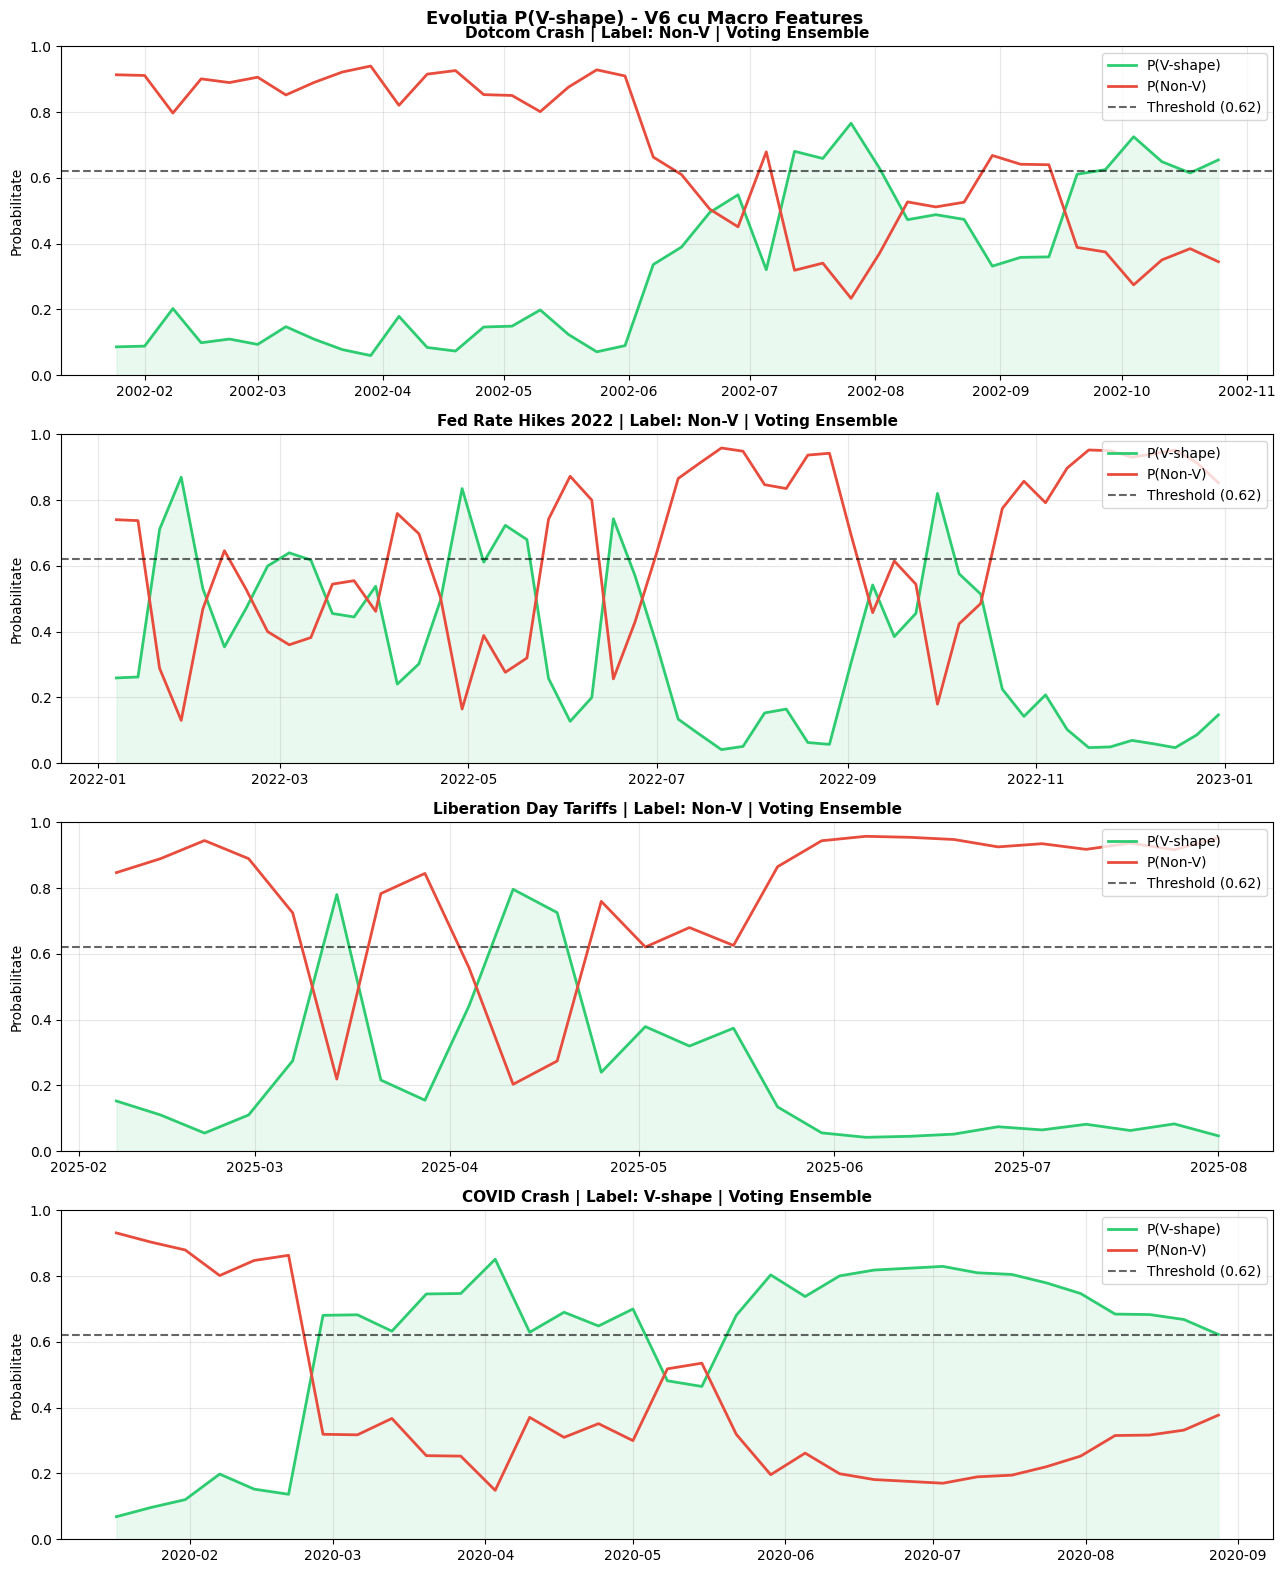

Salvat: plots/v6_probabilities_per_event.png


In [12]:
best_model = results[best_model_name]['model']
best_proba = results[best_model_name]['y_proba']

proba_df = pd.DataFrame({
    'P_VShape'  : best_proba,
    'P_NonV'    : 1 - best_proba,
    'event_name': test_df['event_name'].values,
    'true_label': test_df['label'].values
}, index=test_df.index)

test_event_names = test_df['event_name'].unique()
fig, axes = plt.subplots(len(test_event_names), 1, figsize=(13, 4 * len(test_event_names)))
if len(test_event_names) == 1:
    axes = [axes]

for ax, event in zip(axes, test_event_names):
    ev      = proba_df[proba_df['event_name'] == event]
    dom_lbl = 'V-shape' if ev['true_label'].mode()[0] == 1 else 'Non-V'

    ax.plot(ev.index, ev['P_VShape'], color='#2ecc71', linewidth=2, label='P(V-shape)')
    ax.plot(ev.index, ev['P_NonV'],   color='#e74c3c', linewidth=2, label='P(Non-V)')
    ax.axhline(optimal_threshold, color='black', linestyle='--', alpha=0.6,
               label='Threshold (' + str(round(optimal_threshold, 2)) + ')')
    ax.fill_between(ev.index, ev['P_VShape'], alpha=0.1, color='#2ecc71')
    ax.set_title(
        event + ' | Label: ' + dom_lbl + ' | ' + best_model_name,
        fontsize=11, fontweight='bold'
    )
    ax.set_ylabel('Probabilitate')
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Evolutia P(V-shape) - v5 cu Macro Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/v5_probabilities_per_event.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/v5_probabilities_per_event.png')

## 10. Salvare Model

In [13]:
pickle.dump(results[best_model_name]['model'], open('models/v5_best_model.pkl', 'wb'))
pickle.dump(scaler,                            open('models/v5_scaler.pkl',     'wb'))
pickle.dump(ensemble,                          open('models/v5_ensemble.pkl',   'wb'))

meta = {
    'model_name'        : best_model_name,
    'auc'               : round(results[best_model_name]['auc'], 4),
    'accuracy'          : round(results[best_model_name]['acc'], 4),
    'optimal_threshold' : round(float(optimal_threshold), 2),
    'feature_cols'      : feature_cols,
    'features_dropped'  : FEATURES_TO_DROP,
    'macro_features'    : macro_features,
    'v_threshold'       : 0.05,
    'forward_days'      : 60,
    'frequency'         : 'weekly',
    'top3_ensemble'     : top3_names,
    'classes'           : {0: 'Non-V', 1: 'V-shape'}
}
with open('models/v5_model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Fisiere salvate in models/:')
print('  v5_best_model.pkl')
print('  v5_scaler.pkl')
print('  v5_ensemble.pkl')
print('  v5_model_meta.json')

Fisiere salvate in models/:
  v6_best_model.pkl
  v6_scaler.pkl
  v6_ensemble.pkl
  v6_model_meta.json


## 11. Rezumat Final V4 vs v5

In [14]:
separator = '=' * 60
print('REZUMAT COMPARATIV V4 vs v5')
print(separator)

rows = []
for name in results:
    rows.append({
        'Model'   : name,
        'V4 AUC'  : v4_aucs[name],
        'v5 AUC'  : round(results[name]['auc'], 3),
        'Delta'   : round(results[name]['auc'] - v4_aucs[name], 3),
        'v5 Acc'  : round(results[name]['acc'], 3)
    })

summary = pd.DataFrame(rows).sort_values('v5 AUC', ascending=False).reset_index(drop=True)
summary.index += 1
print(summary.to_string())

print('\nBaseline random AUC: 0.500')
print('V4 best AUC (LightGBM):     0.764')
print('v5 best AUC (' + best_model_name + '):', round(results[best_model_name]['auc'], 3))
print('Threshold optim v5:', round(float(optimal_threshold), 2))
print('\nFeatures eliminate (redundante):', FEATURES_TO_DROP)
print('Features macro adaugate:', macro_features)

REZUMAT COMPARATIV V4 vs V6
                 Model  V4 AUC  V6 AUC  Delta  V6 Acc
1      Voting Ensemble   0.751   0.804  0.053   0.742
2          Naive Bayes   0.724   0.778  0.054   0.735
3             LightGBM   0.764   0.754 -0.010   0.748
4        Random Forest   0.693   0.675 -0.018   0.669
5  Logistic Regression   0.536   0.664  0.128   0.543
6              SVM RBF   0.695   0.523 -0.172   0.490

Baseline random AUC: 0.500
V4 best AUC (LightGBM):     0.764
V6 best AUC (Voting Ensemble): 0.804
Threshold optim V6: 0.62

Features eliminate (redundante): ['Dist_52w_High', 'Realized_Vol_10d']
Features macro adaugate: ['Yield_Curve', 'Yield_Curve_Change', 'Jobless_Ratio', 'Credit_Spread', 'Dollar_Change', 'Fed_Rate']
